In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')
order_products = pd.read_csv('order_products.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')



In [29]:
p_c = products.merge(order_products, on='product_id')

p_c

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered
0,1,Chocolate Sandwich Cookies,61,19,1107,7,0
1,1,Chocolate Sandwich Cookies,61,19,5319,3,1
2,1,Chocolate Sandwich Cookies,61,19,7540,4,1
3,1,Chocolate Sandwich Cookies,61,19,9228,2,0
4,1,Chocolate Sandwich Cookies,61,19,9273,30,0
...,...,...,...,...,...,...,...
32434484,49688,Fresh Foaming Cleanser,73,11,3111954,3,0
32434485,49688,Fresh Foaming Cleanser,73,11,3122003,20,0
32434486,49688,Fresh Foaming Cleanser,73,11,3166828,5,1
32434487,49688,Fresh Foaming Cleanser,73,11,3290206,10,0


In [30]:
p_com = p_c.groupby('product_name').agg(nombre_produits = pd.NamedAgg("product_id", "size"))

prod_com = p_com.drop_duplicates()



# Recherchons pour commencer les produits qui sont les plus commandés de l'épicerie.

In [31]:
c = prod_com[prod_com["nombre_produits"] > 140000]
c

,nombre_produits
product_name,
Bag of Organic Bananas,379450
Banana,472565
Large Lemon,152657
Limes,140627
Organic Avocado,176815
Organic Baby Spinach,241921
Organic Hass Avocado,213584
Organic Strawberries,264683
Strawberries,142951


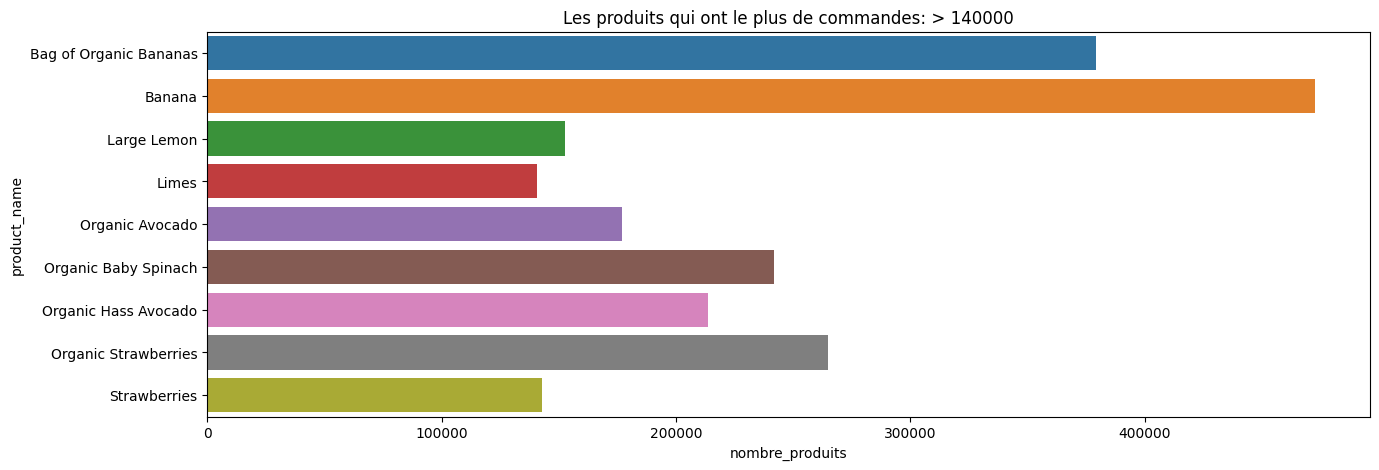

In [32]:
plt.figure(figsize=(15, 5))
sns.barplot(x="nombre_produits" , y="product_name", data=c,hue="product_name")
plt.title('Les produits qui ont le plus de commandes: > 140000')
plt.show()

# Les produits "organics" ou frais l'emportent avec minimum 140000 commandes.

# Interessons-nous à présent aux produits qui sont les moins commandés de l'épicerie.

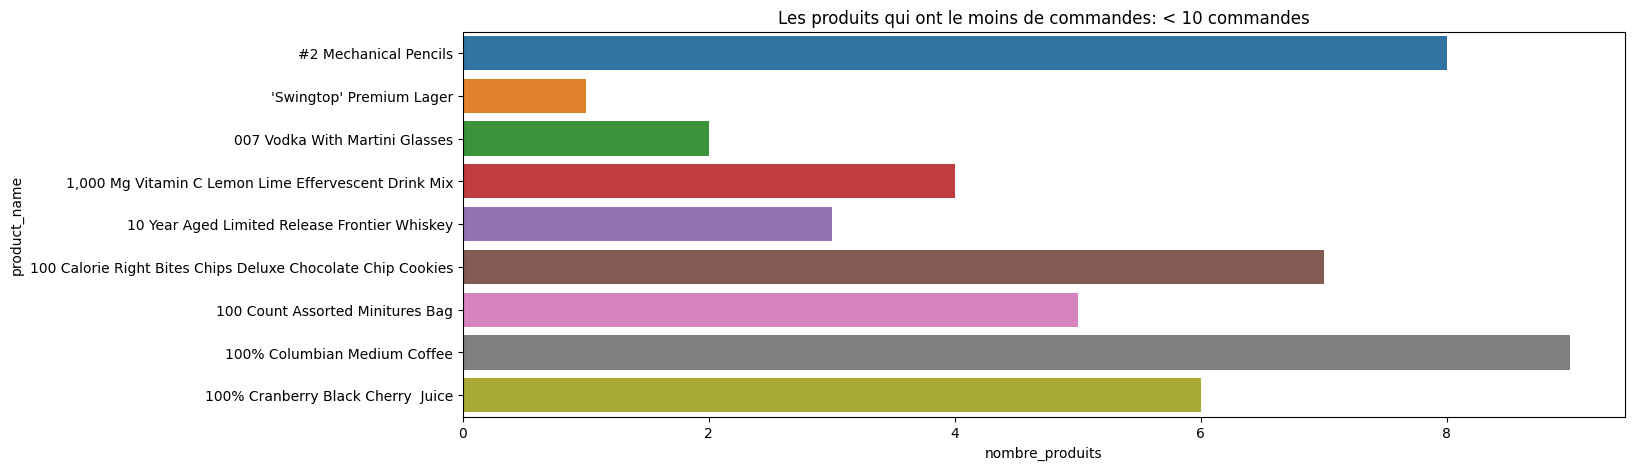

In [33]:
d = prod_com[prod_com["nombre_produits"] < 10]

plt.figure(figsize=(15, 5))
sns.barplot(x="nombre_produits" , y="product_name", data=d,hue="product_name")
plt.title('Les produits qui ont le moins de commandes: < 10 commandes')
plt.show()

# Notre top 09 des produits les moins commandés sont des produits non-organics.

# A quel moment quel moment on achète le plus ?

In [34]:
o = orders.groupby('order_dow').agg(nombre_commandes = pd.NamedAgg("order_dow", "size")).head(-1)
o

,nombre_commandes
order_dow,
0,600905
1,587478
2,467259
3,436972
4,426339
5,453368
6,448761


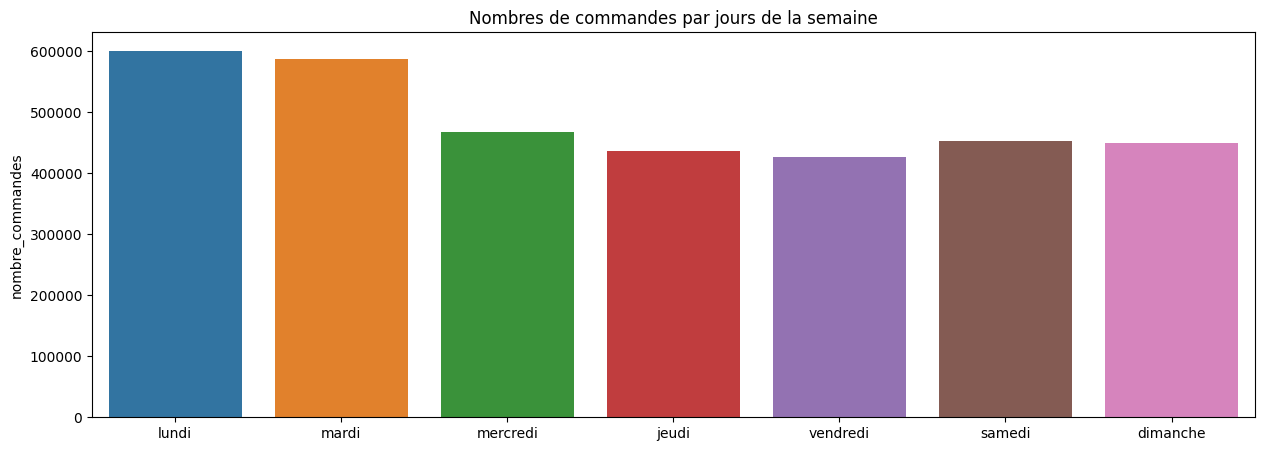

In [35]:
days = ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]

plt.figure(figsize=(15, 5))
sns.barplot(x=days, y="nombre_commandes", data=o,hue=days)
plt.title('Nombres de commandes par jours de la semaine')
plt.show()

# Il y a plus d'affluence dans l'épicerie en début de semaine, précisément les lundis et les mardis.

# A quel heure on achète le plus ?

In [36]:
i = orders.groupby('order_hour_of_day').agg(num_h = pd.NamedAgg("order_hour_of_day", "size"))
i

,num_h
order_hour_of_day,
0,22758
1,12398
2,7539
3,5474
4,5527
5,9569
6,30529
7,91868
8,178201


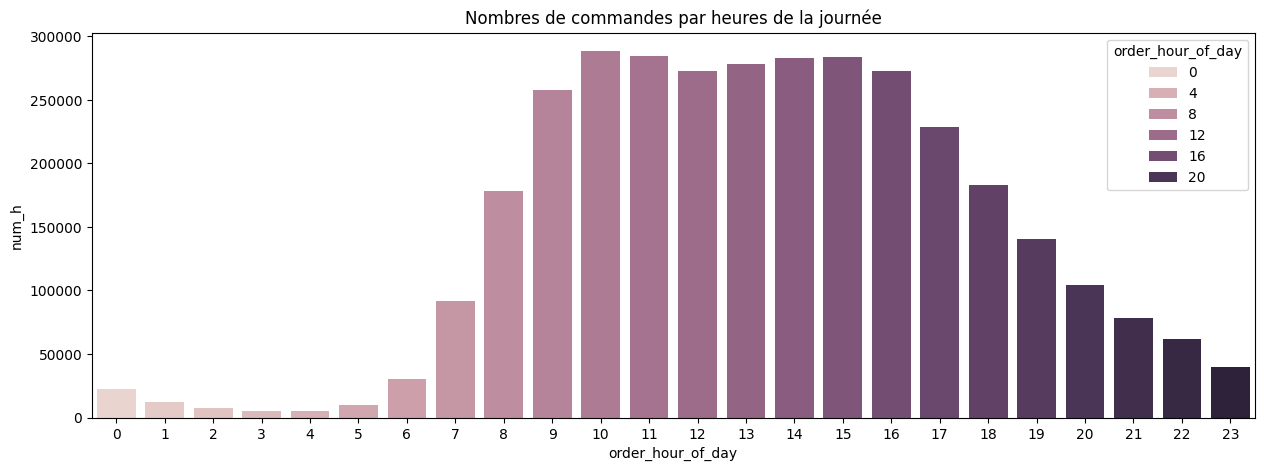

In [37]:
plt.figure(figsize=(15, 5))
sns.barplot(x="order_hour_of_day" , y="num_h", data=i, hue="order_hour_of_day")
plt.title('Nombres de commandes par heures de la journée')
plt.show()

# Ce graphe montre que chaque jour, il y a beaucoup de commandes entre 07h et 21h mais encore plus entre 09h et 17h.

# Il y a t'il plus de commandes que de rachats ?

In [38]:
p = p_c[p_c['reordered']==1]
b = order_products.groupby('reordered').agg(nombre_de_produits = pd.NamedAgg('reordered', 'size'))
b

,nombre_de_produits
reordered,
0,13307953
1,19126536


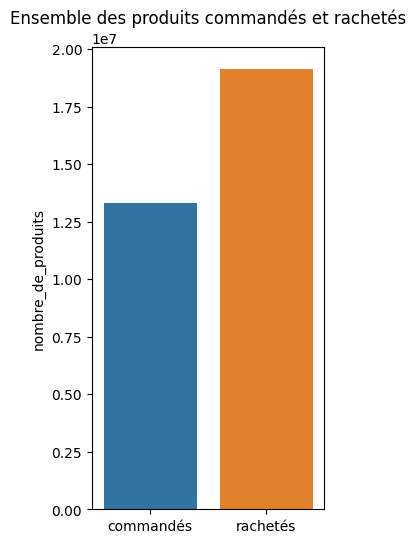

In [57]:
r = ["commandés", "rachetés"]

plt.figure(figsize=(3, 6))
sns.barplot(x=r , y="nombre_de_produits", data=b, hue=r)
plt.title('Ensemble des produits commandés et rachetés')
plt.show()

# Les utilisateurs ont tendance à acheter à nouveau les articles qu'ils achètent déjà.

# Quels sont les produits que les clients achètent à nouveau ?

In [40]:
p = p_c[p_c['reordered']==1]
c = p.groupby(['reordered', 'product_name']).agg(nombre_de_fois_réachetés = pd.NamedAgg('reordered', 'size')).reset_index()
c

,reordered,product_name,nombre_de_fois_réachetés
0,1,#2 Coffee Filters,257
1,1,#2 Cone White Coffee Filters,3
2,1,#4 Natural Brown Coffee Filters,89
3,1,& Go! Hazelnut Spread + Pretzel Sticks,87
4,1,(70% Juice!) Mountain Raspberry Juice Squeeze,16
...,...,...,...
45300,1,with Xylitol Unwrapped Original Flavor 50 Stic...,17
45301,1,with Xylitol Unwrapped Spearmint 50 Sticks Sug...,19
45302,1,with Xylitol Watermelon Twist 18 Sticks Sugar ...,31
45303,1,with a Splash of Mango Coconut Water,6


In [41]:
e = c[c["nombre_de_fois_réachetés"] > 100000]
e

,reordered,product_name,nombre_de_fois_réachetés
3058,1,Bag of Organic Bananas,315913
3247,1,Banana,398609
20302,1,Large Lemon,106255
26116,1,Organic Avocado,134044
26151,1,Organic Baby Spinach,186884
27532,1,Organic Hass Avocado,170131
28550,1,Organic Raspberries,105409
29079,1,Organic Strawberries,205845
29597,1,Organic Whole Milk,114510


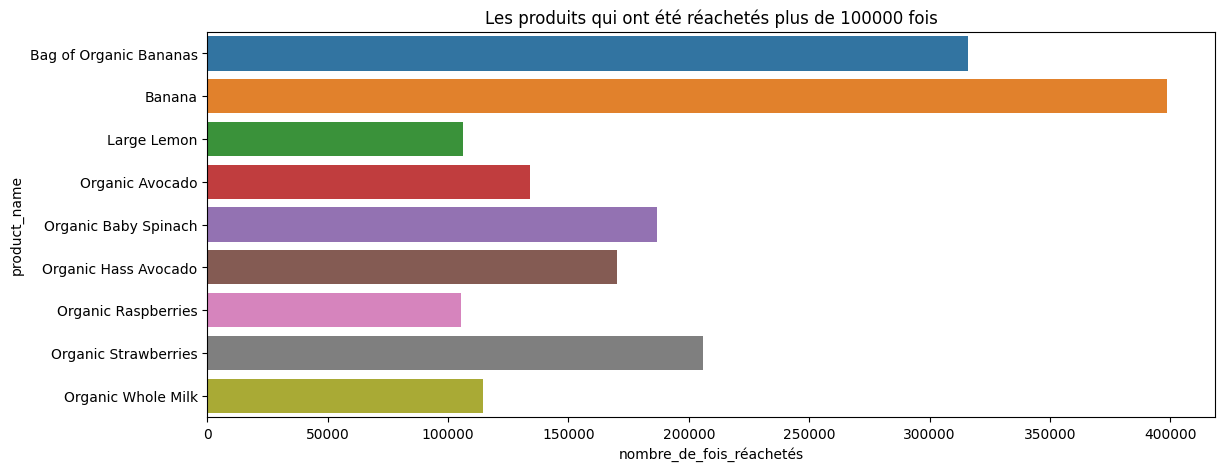

In [42]:
plt.figure(figsize=(13, 5))
sns.barplot(x="nombre_de_fois_réachetés" , y="product_name", data=e,hue="product_name")
plt.title('Les produits qui ont été réachetés plus de 100000 fois')
plt.show()

# Les produits frais sont les plus rachetés, les bananes sont encore en tête avec plus de 400000 commandes.

# Passons aux départements de l'épicerie, lequel regroupe les produits les plus achétés ?

In [43]:
jsp = p_c.merge(departments, on='department_id')
jsp

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered,department
0,1,Chocolate Sandwich Cookies,61,19,1107,7,0,snacks
1,1,Chocolate Sandwich Cookies,61,19,5319,3,1,snacks
2,1,Chocolate Sandwich Cookies,61,19,7540,4,1,snacks
3,1,Chocolate Sandwich Cookies,61,19,9228,2,0,snacks
4,1,Chocolate Sandwich Cookies,61,19,9273,30,0,snacks
...,...,...,...,...,...,...,...,...
32434484,49688,Fresh Foaming Cleanser,73,11,3111954,3,0,personal care
32434485,49688,Fresh Foaming Cleanser,73,11,3122003,20,0,personal care
32434486,49688,Fresh Foaming Cleanser,73,11,3166828,5,1,personal care
32434487,49688,Fresh Foaming Cleanser,73,11,3290206,10,0,personal care


In [44]:
jsp1 = jsp.groupby('department').agg(nbr_prod_dep = pd.NamedAgg("department", "size"))

jsp1

,nbr_prod_dep
department,
alcohol,153696
babies,423802
bakery,1176787
beverages,2690129
breakfast,709569
bulk,34573
canned goods,1068058
dairy eggs,5414016
deli,1051249


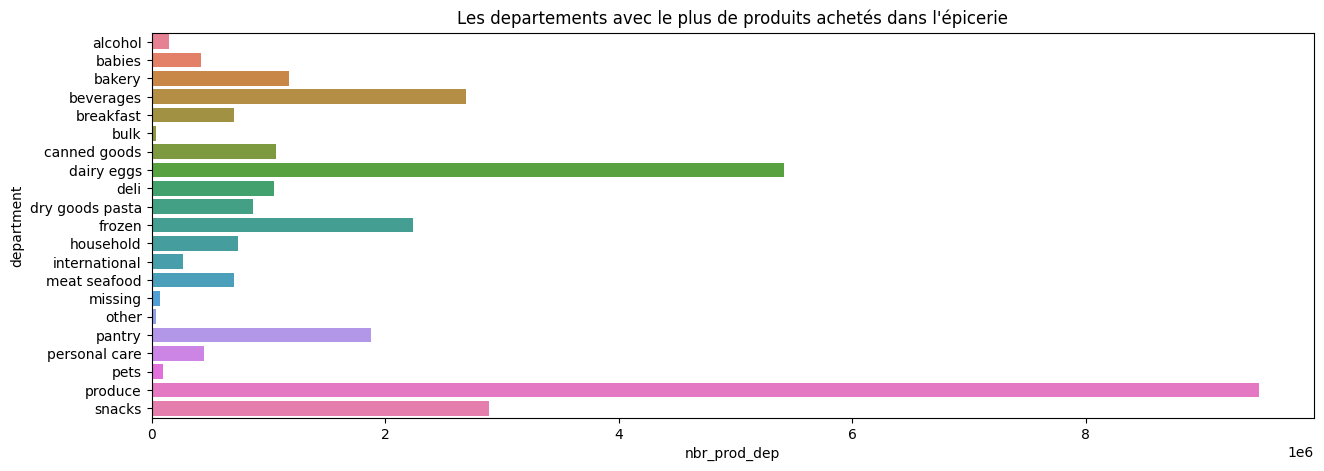

In [45]:
plt.figure(figsize=(15, 5))
sns.barplot(x="nbr_prod_dep" , y="department", data=jsp1, hue="department")
plt.title("Les departements avec le plus de produits achetés dans l'épicerie")
plt.show()

# Le département 'produce' est éfinitivement celui qui a le plus de commandes, il est suivi de dairy eggs, snacks, beverages, frozen et pantry.

# Qu'en est-il des rayons ?

In [46]:
jsp2 = jsp.merge(aisles, on='aisle_id')
jsp2

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,1107,7,0,snacks,cookies cakes
1,1,Chocolate Sandwich Cookies,61,19,5319,3,1,snacks,cookies cakes
2,1,Chocolate Sandwich Cookies,61,19,7540,4,1,snacks,cookies cakes
3,1,Chocolate Sandwich Cookies,61,19,9228,2,0,snacks,cookies cakes
4,1,Chocolate Sandwich Cookies,61,19,9273,30,0,snacks,cookies cakes
...,...,...,...,...,...,...,...,...,...
32434484,49688,Fresh Foaming Cleanser,73,11,3111954,3,0,personal care,facial care
32434485,49688,Fresh Foaming Cleanser,73,11,3122003,20,0,personal care,facial care
32434486,49688,Fresh Foaming Cleanser,73,11,3166828,5,1,personal care,facial care
32434487,49688,Fresh Foaming Cleanser,73,11,3290206,10,0,personal care,facial care


In [47]:
jsp3 = jsp2.groupby('aisle').agg(nbr_prod_aisle = pd.NamedAgg("aisle", "size"))
jsp3

,nbr_prod_aisle
aisle,
air fresheners candles,19851
asian foods,166607
baby accessories,8160
baby bath body care,8581
baby food formula,382456
...,...
trash bags liners,32081
vitamins supplements,45059
water seltzer sparkling water,841533


In [48]:
j = jsp3[jsp3["nbr_prod_aisle"] > 600000]
j1 = j.sort_values(by="nbr_prod_aisle", ascending = False)
j1

,nbr_prod_aisle
aisle,
fresh fruits,3642188
fresh vegetables,3418021
packaged vegetables fruits,1765313
yogurt,1452343
packaged cheese,979763
milk,891015
water seltzer sparkling water,841533
chips pretzels,722470
soy lactosefree,638253


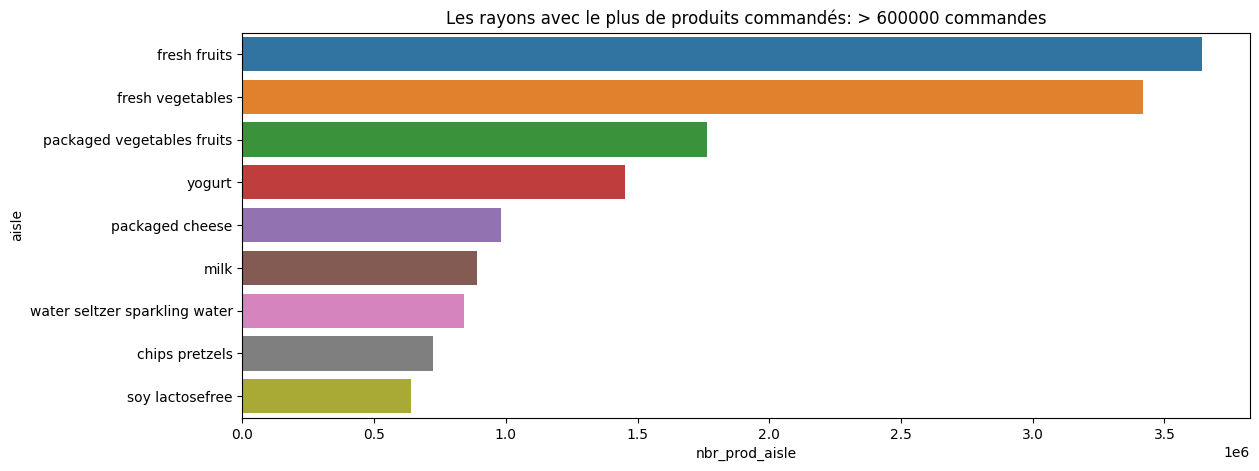

In [49]:
plt.figure(figsize=(13, 5))
sns.barplot(x="nbr_prod_aisle" , y="aisle", data=j1, hue="aisle")
plt.title('Les rayons avec le plus de produits commandés: > 600000 commandes')
plt.show()

# Le rayon des fruits frais est celui qui rassemble de plus d'achats avec plus de 3M6 d'achats, il est suivi de près par celui des légumes frais avec plus de 3M5 d'achats.

# Combien de temps suffit à un utilisateur pour faire des achats à nouveau dans l'épicerie ?

In [50]:
day = p_c.merge(orders, on='order_id')

day

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,Chocolate Sandwich Cookies,61,19,1107,7,0,38259,prior,2,1,11,7.0
1,1,Chocolate Sandwich Cookies,61,19,5319,3,1,196224,prior,65,1,14,1.0
2,1,Chocolate Sandwich Cookies,61,19,7540,4,1,138499,prior,8,0,14,7.0
3,1,Chocolate Sandwich Cookies,61,19,9228,2,0,79603,prior,2,2,10,30.0
4,1,Chocolate Sandwich Cookies,61,19,9273,30,0,50005,prior,1,1,15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32434484,49688,Fresh Foaming Cleanser,73,11,3111954,3,0,79411,prior,6,4,19,4.0
32434485,49688,Fresh Foaming Cleanser,73,11,3122003,20,0,146323,prior,3,1,16,24.0
32434486,49688,Fresh Foaming Cleanser,73,11,3166828,5,1,188073,prior,7,1,15,30.0
32434487,49688,Fresh Foaming Cleanser,73,11,3290206,10,0,121646,prior,3,0,9,14.0


In [51]:
z = day.groupby('days_since_prior_order').agg(nombre = pd.NamedAgg("days_since_prior_order", "size"))
z

,nombre
days_since_prior_order,
0.0,448698
1.0,941116
2.0,1464875
3.0,1877881
4.0,2080560
5.0,2126420
6.0,2519939
7.0,3479504
8.0,1933815


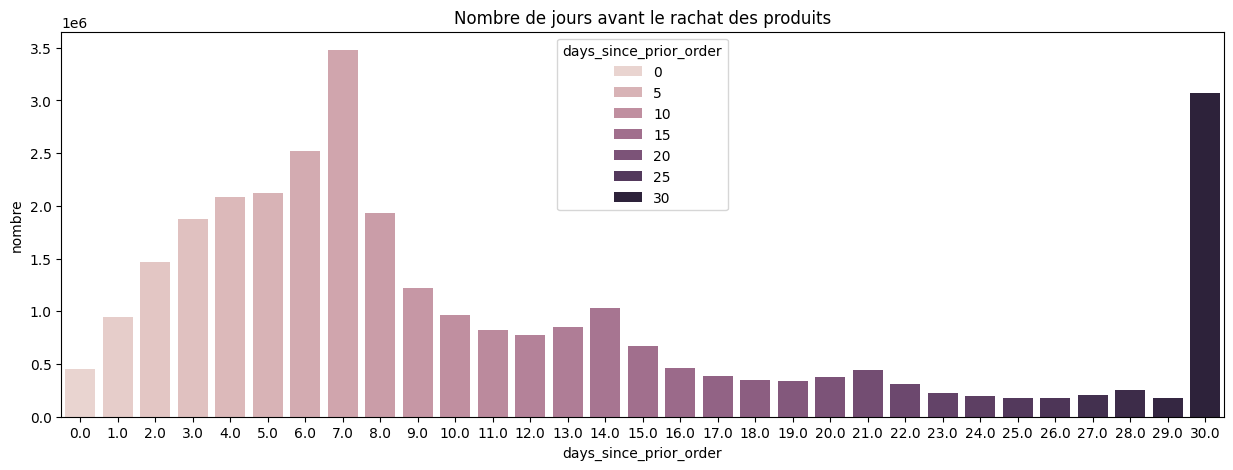

In [52]:
plt.figure(figsize=(15, 5))
sns.barplot(x="days_since_prior_order", y="nombre", data=z, hue="days_since_prior_order")
plt.title('Nombre de jours avant le rachat des produits')
plt.show()

# Les clients ont tendance à acheter 07j  où 30j après leur premier achat.

In [53]:
s = order_products.groupby('order_id').agg(nbrProd= pd.NamedAgg("add_to_cart_order", "size"))
s

,nbrProd
order_id,
2,9
3,8
4,13
5,26
6,3
...,...
3421079,1
3421080,9
3421081,7


In [75]:
y = day.groupby(day['add_to_cart_order'] == 1).agg(nombre_de_fois = pd.NamedAgg("product_name", "size"))
y

,nombre_de_fois
add_to_cart_order,
False,29219615
True,3214874


In [68]:
z = y[y['nombre_de_fois']> 30000]
z

,add_to_cart_order,product_name,nombre_de_fois
2891,1,Bag of Organic Bananas,78988
3068,1,Banana,110916
27369,1,Organic Whole Milk,30927
44680,2,Bag of Organic Bananas,64337
44855,2,Banana,80432
86335,3,Bag of Organic Bananas,48972
86508,3,Banana,58577
127974,4,Bag of Organic Bananas,36955
128145,4,Banana,43653
169700,5,Banana,33647
